# 08 - Weights & Biases Experiment Tracking

This notebook shows a compact end-to-end ML run tracked with **Weights & Biases (W&B)**.

## What it demonstrates
- run initialization
- configuration logging
- training / validation metric logging
- confusion matrix logging
- artifact logging
- online vs offline execution modes

The training example uses a small PyTorch classifier on FashionMNIST so the tracking workflow is the star of the show.


In [1]:
# Colab setup
%pip -q install -U torch torchvision wandb scikit-learn matplotlib pandas


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 530.7/530.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.1/366.1 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.9/169.9 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.5/196.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.3/188.3 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214

In [2]:
import os
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import confusion_matrix, classification_report

import wandb

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## W&B setup

In Colab you have two practical options:

- **online mode**: run `wandb.login()` and log to your real account
- **offline mode**: write the run locally and sync later

For a class demo, offline mode is often safer if you do not want to expose credentials on screen.


In [3]:
# Choose ONE of these approaches.

# Option A: online mode
# wandb.login()

# Option B: offline mode
os.environ["WANDB_MODE"] = "online"


In [6]:
config = {
    "batch_size": 128,
    "epochs": 6,
    "learning_rate": 1e-3,
    "hidden_dim": 256,
    "dropout": 0.3,
    "dataset_limit_train": 12000,
    "dataset_limit_test": 3000,
}

run = wandb.init(
    project="cmpe258-advanced-nn",
    name="fashionmnist-wandb-demo",
    config=config,
)


## Dataset and model


In [7]:
transform = transforms.ToTensor()
train_full = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_full = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

train_subset = torch.utils.data.Subset(train_full, list(range(config["dataset_limit_train"])))
test_subset = torch.utils.data.Subset(test_full, list(range(config["dataset_limit_test"])))

train_len = 10000
val_len = len(train_subset) - train_len
train_set, val_set = random_split(train_subset, [train_len, val_len], generator=torch.Generator().manual_seed(SEED))

train_loader = DataLoader(train_set, batch_size=config["batch_size"], shuffle=True)
val_loader = DataLoader(val_set, batch_size=256, shuffle=False)
test_loader = DataLoader(test_subset, batch_size=256, shuffle=False)

class WandbMLP(nn.Module):
    def __init__(self, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 10),
        )

    def forward(self, x):
        return self.net(x)

model = WandbMLP(config["hidden_dim"], config["dropout"]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
criterion = nn.CrossEntropyLoss()


In [8]:
wandb.watch(model, log="all", log_freq=100)


In [9]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    total = 0
    correct = 0
    losses = []
    all_preds = []
    all_targets = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item())

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_targets.extend(y.cpu().numpy().tolist())

    return np.mean(losses), correct / total, all_targets, all_preds


## Training loop with W&B logging


In [10]:
best_state = None
best_val_acc = -1.0

for epoch in range(config["epochs"]):
    model.train()
    batch_losses = []

    for step, (x, y) in enumerate(train_loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

        if step % 25 == 0:
            wandb.log(
                {
                    "train/batch_loss": loss.item(),
                    "train/epoch": epoch,
                    "train/step": epoch * len(train_loader) + step,
                }
            )

    train_loss = float(np.mean(batch_losses))
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    wandb.log(
        {
            "epoch": epoch,
            "train/loss": train_loss,
            "val/loss": val_loss,
            "val/accuracy": val_acc,
            "learning_rate": optimizer.param_groups[0]["lr"],
        }
    )

    print(f"epoch={epoch+1} train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        torch.save(best_state, "best_model.pt")


epoch=1 train_loss=0.9392 val_loss=0.6219 val_acc=0.7710
epoch=2 train_loss=0.5825 val_loss=0.5370 val_acc=0.8085
epoch=3 train_loss=0.5220 val_loss=0.5108 val_acc=0.8115
epoch=4 train_loss=0.4847 val_loss=0.4616 val_acc=0.8280
epoch=5 train_loss=0.4459 val_loss=0.4651 val_acc=0.8360
epoch=6 train_loss=0.4199 val_loss=0.4263 val_acc=0.8410


In [11]:
model.load_state_dict(best_state)
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader)

wandb.log(
    {
        "test/loss": test_loss,
        "test/accuracy": test_acc,
    }
)

print("test_acc:", test_acc)


test_acc: 0.8483333333333334


## Confusion matrix and artifact logging


In [12]:
class_names = train_full.classes

wandb.log({
    "confusion_matrix": wandb.plot.confusion_matrix(
        probs=None,
        y_true=y_true,
        preds=y_pred,
        class_names=class_names,
    )
})

artifact = wandb.Artifact("fashionmnist-best-model", type="model")
artifact.add_file("best_model.pt")
wandb.log_artifact(artifact)


<Artifact fashionmnist-best-model>

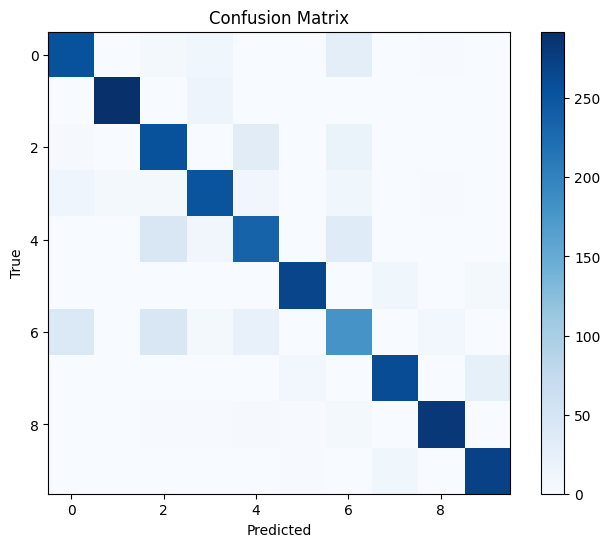

,metric,value
0,best_val_acc,0.841000
1,test_loss,0.438455
2,test_acc,0.848333


In [13]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

pd.DataFrame({
    "metric": ["best_val_acc", "test_loss", "test_acc"],
    "value": [best_val_acc, test_loss, test_acc],
})


In [14]:
print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

 T-shirt/top       0.82      0.84      0.83       302
     Trouser       0.97      0.95      0.96       308
    Pullover       0.72      0.82      0.76       310
       Dress       0.86      0.84      0.85       298
        Coat       0.77      0.72      0.75       324
      Sandal       0.95      0.94      0.95       285
       Shirt       0.64      0.60      0.62       298
     Sneaker       0.92      0.89      0.90       293
         Bag       0.95      0.95      0.95       297
  Ankle boot       0.90      0.95      0.93       285

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



In [15]:
run.finish()
print("Finished W&B run. In offline mode, sync later with:")
print("wandb sync wandb/offline-run-*")


epoch,▁▂▄▅▇█
learning_rate,▁▁▁▁▁▁
test/accuracy,▁
test/loss,▁
train/batch_loss,█▃▂▂▂▃▂▁▂▁▂▂▂▁▂▁▁▁▁▂▁▂▁▁
train/epoch,▁▁▁▁▂▂▂▂▄▄▄▄▅▅▅▅▇▇▇▇████
train/loss,█▃▂▂▁▁
train/step,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
val/accuracy,▁▅▅▇██
val/loss,█▅▄▂▂▁
epoch,5


Finished W&B run. In offline mode, sync later with:
wandb sync wandb/offline-run-*


## What to say in the video

- show the config dictionary first
- explain `wandb.init(...)`
- point out `wandb.watch(model)` for gradients/parameter tracking
- explain metric logging inside the training loop
- show the confusion matrix and artifact logging
- mention online vs offline mode for safe classroom demos

That is enough to satisfy the W&B requirement without turning the notebook into a ceremonial tribute to dashboards.
